# Section 1: Canny Edge Detector

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
import cv2

img=cv2.imread('cameraman.png',cv2.IMREAD_GRAYSCALE).astype(np.float32)
img_disp=img.copy()
img=img/255.0

## 1: Effect of Smoothing and Operator Choice

### 1.1 Finite Difference on Unsmoothed Image

In [2]:
Kx=np.array([[-1,0,1]])
Ky=np.array([[-1], [0], [1]])

Ix_fd=ndimage.convolve(img,Kx,mode='constant',cval=0.0)
Iy_fd=ndimage.convolve(img,Ky,mode='constant',cval=0.0)
M_fd=np.sqrt(Ix_fd**2+Iy_fd**2)
theta_fd=np.arctan2(Iy_fd,Ix_fd)

### 1.2 Sobel on Unsmoothed Image

In [3]:
Kx_sobel=np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
Ky_sobel=np.array([[-1,-2,-1],[0,0,0],[1,2,1]])

Ix_sob=ndimage.convolve(img,Kx_sobel,mode='constant',cval=0.0)
Iy_sob=ndimage.convolve(img,Ky_sobel,mode='constant',cval=0.0)
M_sob=np.sqrt(Ix_sob**2+Iy_sob**2)
theta_sob=np.arctan2( Iy_sob,Ix_sob)

### 1.3 Gaussian Smoothing + Finite Difference

In [ ]:
img_smooth=ndimage.gaussian_filter(img,sigma=0.33,truncate=1.0)
Ix_fd_smooth=ndimage.convolve(img_smooth,Kx,mode='constant',cval=0.0)
Iy_fd_smooth=ndimage.convolve(img_smooth,Ky,mode='constant',cval=0.0)
M_fd_smooth=np.sqrt(Ix_fd_smooth**2 + Iy_fd_smooth**2)

### Plotting the Three Gradient Magnitudes

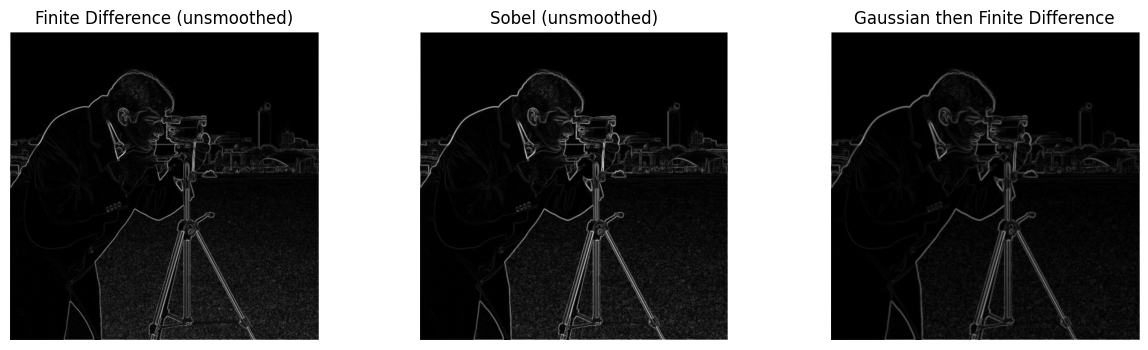

In [9]:
plt.figure(figsize=(15,4))
plt.subplot(131)
plt.imshow(M_fd,cmap='gray')
plt.title('Finite Difference (unsmoothed)')
plt.axis('off')

plt.subplot(132)
plt.imshow(M_sob,cmap='gray')
plt.title('Sobel (unsmoothed)')
plt.axis('off')
plt.subplot(133)
plt.imshow(M_fd_smooth,cmap='gray')
plt.title('Gaussian then Finite Difference')
plt.axis('off')
plt.show()

Answer: Sobel is more efficient because it performs both smoothing and differentiation in a single 3×3 convolution and the two‑step approach requires a Gaussian convolution plus two finite‑difference convolutions which is roughly triple the operations.

## 2. Directional Quantization (4 sectors, 45° each)

We use the gradients from Sobel (unsmoothed) to compute angles and then map them to [0°,180°), and do the quantize into 4 sectors.

In [10]:
angle_deg=np.degrees(theta_sob)%180

sector_4=np.floor(angle_deg/45).astype(int)
sector_4=np.clip(sector_4,0,3)

### Color‑coded visualization using a cyclic colormap

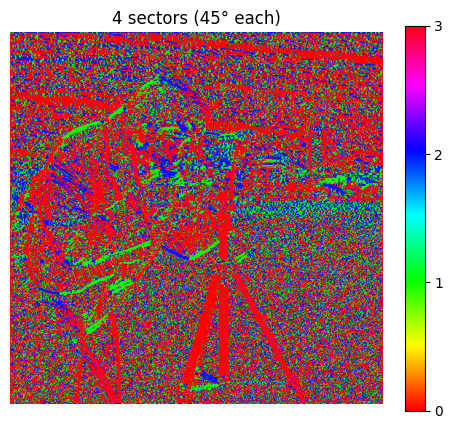

In [11]:
from matplotlib.colors import Normalize
plt.figure(figsize=(6,5))
plt.imshow(sector_4,cmap='hsv',norm=Normalize(vmin=0,vmax=3))
plt.title('4 sectors (45° each)')
plt.colorbar(ticks=[0,1,2,3])
plt.axis('off')
plt.show()

## 3. Non‑Maximum Suppression (NMS) with 4‑sector directions

For each sector we define the two neighbor pixels along the gradient direction.
The mapping is:

Sector 0 (angles 0–45): gradient approx. horizontal ie neighbors left/right ie offsets (0,1) and (0,-1) in (row, col) notation.

Sector 1 (45–90): gradient approx. 45 ie neighbors top‑right / bottom‑left ie offsets (-1,1) and (1,-1).

Sector 2 (90–135): gradient approx. vertical ie neighbors top/bottom ie offsets (-1,0) and (1,0).

Sector 3 (135 – 180): gradient approx. 135 ie neighbors top‑left / bottom‑right ie offsets (-1,-1) and (1,1).

In [12]:
def non_max_suppression_4(M,sector):
   h,w=M.shape
   suppressed=np.zeros_like(M)

   offsets=[(0,1),(-1,1),(-1,0),(-1,-1)]
   for i in range(1,h-1):
       for j in range(1,w-1):
           s=sector[i,j]
           dy,dx=offsets[s]
           p1=M[i+dy,j+dx]
           p2=M[i-dy,j-dx]
           if M[i,j]>p1 and M[i,j]>p2:
               suppressed[i,j]=M[i,j]
   return suppressed

Applying NMS to the Sobel magnitude:

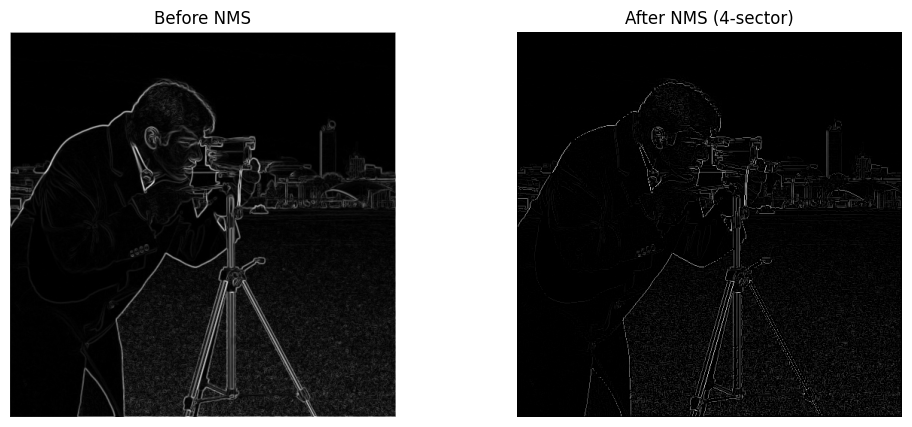

In [13]:
M_nms_4=non_max_suppression_4(M_sob,sector_4)
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.imshow(M_sob,cmap='gray')
plt.title('Before NMS')
plt.axis('off')
plt.subplot(122)
plt.imshow(M_nms_4,cmap='gray')
plt.title('After NMS (4‑sector)')
plt.axis('off')
plt.show()

## 4. Double Thresholding & Iterative Hysteresis

### Normalize magnitude using 98th percentile scaling

In [15]:
p98=np.percentile(M_sob,98)
scale=255.0/p98 if p98>0 else 1.0
M_nms_scaled=np.clip(M_nms_4 * scale, 0, 255)

### Double thresholding

In [16]:
Thigh=200
Tlow=50
strong=M_nms_scaled>Thigh
weak=(M_nms_scaled>Tlow) & (M_nms_scaled<=Thigh)

### Iterative hysteresis (8‑connectivity)

In [17]:
def hysteresis(strong,weak):
   h,w=strong.shape
   edge=strong.copy()
   queue=list(zip(*np.where(edge)))
   neighbors=[(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]
   while queue:
       y,x=queue.pop(0)
       for dy,dx in neighbors:
           ny,nx=y+dy,x+dx
           if 0<=ny<h and 0<=nx<w:
               if weak[ny,nx] and not edge[ny,nx]:
                   edge[ny,nx]=True
                   queue.append((ny,nx))
   return edge

final_edges=hysteresis(strong,weak)

### Diagnostic Edge Map: strong vs. weak‑retained

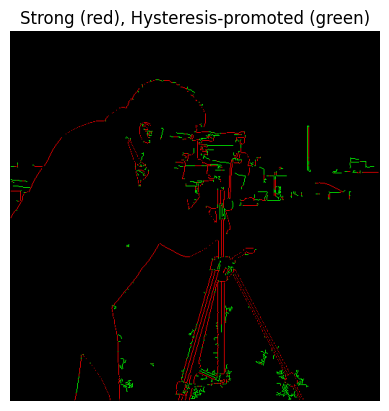

In [19]:
diag=np.zeros((*final_edges.shape,3),dtype=np.uint8)
diag[...,0]=(strong*255).astype(np.uint8)
diag[...,1]=((final_edges & ~strong)*255).astype(np.uint8)
plt.imshow(diag)
plt.title('Strong (red), Hysteresis‑promoted (green)')
plt.axis('off')
plt.show()

## 5. Comparison with OpenCV Canny

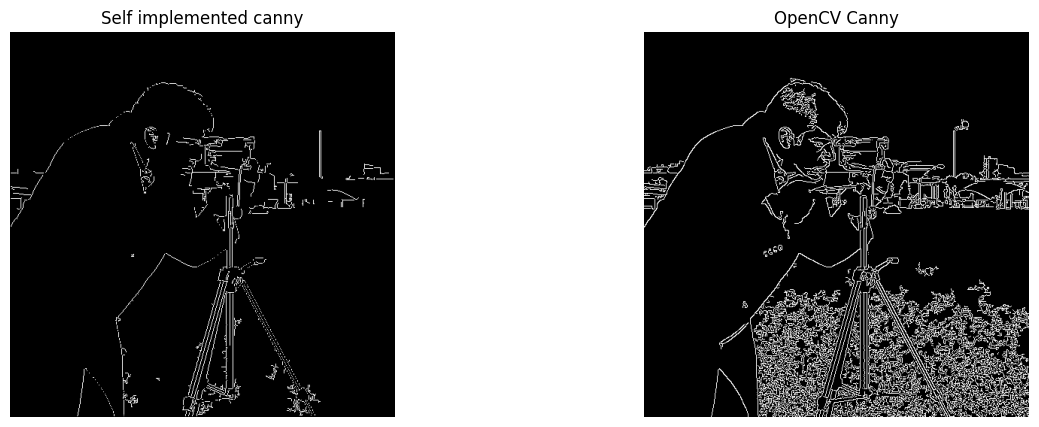

In [21]:
edges_cv=cv2.Canny(img_disp.astype(np.uint8),50,200)
plt.figure(figsize=(15,5))
plt.subplot(121)
plt.imshow(final_edges,cmap='gray')
plt.title('Self implemented canny')
plt.axis('off')
plt.subplot(122)
plt.imshow(edges_cv,cmap='gray')
plt.title('OpenCV Canny')
plt.axis('off')
plt.show()

Discussion Point: Our 4‑sector implementation produces edges that are generally correct, but due to the coarse quantization (45° steps), some diagonal edges show minor fragmentation or stair‑stepping. OpenCV’s result is cleaner and more continuous, likely because it uses more precise interpolation for gradient direction and possibly a finer sector division internally. but anyways, the overall structure is well captured, and the iterative hysteresis successfully connects most of the weak edge segments.